# Phishing URL Detection Pipeline
> Detección de phishing basada en características léxicas de URLs — sin acceso externo en inferencia.
> Fuentes: PhishTank · OpenPhish · URLhaus · Tranco · Cisco Umbrella


In [2]:
# Install missing packages (safe to re-run, skips if already installed)
import importlib, subprocess, sys

REQUIRED = [
    "tldextract",
    "requests",
    "scikit-learn",
    "xgboost",
    "lightgbm",
    "joblib",
    "seaborn",
    "tqdm",
]

missing = [p for p in REQUIRED if importlib.util.find_spec(p.replace('-','_').split('[')[0]) is None]
if missing:
    print(f"Installing: {missing}")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])
    print("Done")
else:
    print("All packages present")


Installing: ['tldextract', 'scikit-learn']
Done


In [3]:
import re, json, warnings, zipfile, io, sys
from pathlib import Path
from urllib.parse import urlparse
from collections import Counter

import numpy as np
import pandas as pd
import requests
import tldextract

from sklearn.model_selection  import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing    import StandardScaler
from sklearn.pipeline         import Pipeline
from sklearn.impute            import SimpleImputer
from sklearn.ensemble         import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.linear_model     import LogisticRegression
from sklearn.metrics          import (
    classification_report, confusion_matrix, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay, precision_recall_curve,
    f1_score, average_precision_score,
)
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

try:
    import xgboost as xgb; HAS_XGB = True
except ImportError:
    HAS_XGB = False

try:
    import lightgbm as lgb; HAS_LGB = True
except ImportError:
    HAS_LGB = False

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

RANDOM_STATE  = 42
TEST_SIZE     = 0.20
TARGET_COL    = "label"
MAX_PER_CLASS = 50_000
INCLUDE_URLHAUS_MALWARE = False

# Definición de directorios primero para evitar NameError
RAW_DIR   = Path("data/raw")
PROC_DIR  = Path("data/processed")
MODEL_DIR = Path("models")
FIG_DIR   = Path("reports/figures")

for _d in [RAW_DIR, PROC_DIR, MODEL_DIR, FIG_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

ISCX_URL = (
    "https://raw.githubusercontent.com/incertum/cyber-matrix-ai"
    "/master/Malicious-URL-Detection-Deep-Learning/data/url_data_mega_deep_learning.csv"
)

NEUTRAL_SUBS = {"www", "www2", "m", "mobile", "wap", "docs", "api", "cdn", "static", "dev"}

# Reputación de dominio: top-10k Tranco.
def _load_tranco_top(n: int = 10_000) -> set:
    p = RAW_DIR / "tranco.csv"
    if not p.exists(): return set()
    try:
        df = pd.read_csv(p, header=None, usecols=[1],
                         names=["d"], dtype=str, nrows=n)
        return set(df["d"].str.lower().str.strip())
    except: return set()

TRANCO_TOP10K = _load_tranco_top()
print(f"Tranco top-10k: {len(TRANCO_TOP10K):,} domains")

print(f"Python {sys.version.split()[0]}")
print(f"XGBoost: {'OK' if HAS_XGB else 'not installed'}   LightGBM: {'OK' if HAS_LGB else 'not installed'}")
print("Environment ready")

Tranco top-10k: 0 domains
Python 3.12.13
XGBoost: OK   LightGBM: OK
Environment ready


## 1 · Fuentes de datos

| Dataset | Tipo | Estado | Actualización | Notas |
|---------|------|--------|---------------|-------|
| **PhishTank** | Phishing verificado | ✅ GET 200 | Diario | HEAD bloqueado por diseño; descarga con GET |
| **OpenPhish** | Phishing activo | ✅ 200 | Continuo | Free tier = 300 URLs; comercial tiene más |
| **URLhaus** | Malware distribution | ✅ 200 | Diario | ⚠️ NO es phishing — es `malware_download`. Opcional. |
| **Tranco Top 1M** | Legítimas | ✅ 200 | Diario | Agregado de Alexa, Majestic, Umbrella, Chrome |
| **Cisco Umbrella** | Legítimas (fallback) | ✅ 200 | Diario | DNS queries, no web traffic |
| **ISCX-URL-2016** | Mixto etiquetado | Kaggle | Estático | ~100k URLs multi-clase |

> **Nota URLhaus**: el feed completo contiene exclusivamente `malware_download` (URLs que sirven ejecutables maliciosos), NO páginas de phishing de robo de credenciales. Actívalo con `INCLUDE_URLHAUS_MALWARE = True` si quieres detectar ambas amenazas.

Para añadir un dataset: depositar en `data/raw/` y agregar un loader en `load_phishing()` o `load_legitimate()` siguiendo el patrón existente.


In [4]:
SOURCES = {
    "iscx": {
        "url":  ISCX_URL,  # URLs reales verificadas — benign + malicious
        "path": RAW_DIR / "iscx_urls.csv",
        "zip":  False,
    },
    "phishtank": {
        "url":  "https://data.phishtank.com/data/online-valid.csv",  # HEAD bloqueado, GET funciona
        "path": RAW_DIR / "phishtank.csv",
        "zip":  False,
    },
    "openphish": {
        "url":  "https://openphish.com/feed.txt",
        "path": RAW_DIR / "openphish.txt",
        "zip":  False,
    },
    "urlhaus": {
        "url":  "https://urlhaus.abuse.ch/downloads/csv/",  # threat=malware_download, NO phishing puro
        "path": RAW_DIR / "urlhaus.csv",
        "zip":  True,
    },
    "tranco": {
        "url":  "https://tranco-list.eu/top-1m.csv.zip",
        "path": RAW_DIR / "tranco.csv",
        "zip":  True,
    },
    "umbrella": {
        "url":  "http://s3-us-west-1.amazonaws.com/umbrella-static/top-1m.csv.zip",
        "path": RAW_DIR / "umbrella.csv",
        "zip":  True,
    },
}


def _unzip_first(content: bytes) -> bytes:
    with zipfile.ZipFile(io.BytesIO(content)) as zf:
        return zf.read(zf.namelist()[0])


def download(key: str, force: bool = False) -> bool:
    cfg  = SOURCES[key]
    path = cfg["path"]
    if path.exists() and path.stat().st_size > 1000 and not force:
        print(f"  cached    {path.name}  ({path.stat().st_size // 1024} KB)")
        return True

    print(f"  fetching  {path.name} ...")
    try:
        r = requests.get(cfg["url"], timeout=120,
                         headers={"User-Agent": "Mozilla/5.0 phishing-research/1.0"})
        r.raise_for_status()
        content = r.content
        if cfg["zip"] or content[:2] == b"PK":
            content = _unzip_first(content)
        path.write_bytes(content)
        print(f"  OK        {path.stat().st_size // 1024} KB")
        return True
    except Exception as exc:
        print(f"  FAILED    {exc}")
        return False


def filter_top_domains(df: pd.DataFrame, top_domains: set) -> pd.DataFrame:
    """Remove phishing rows whose registered domain is already in the top set."""
    if not top_domains:
        print("  Filtrado top-10k: omitido (conjunto Tranco vacío)")
        return df.reset_index(drop=True)

    def is_top(url):
        try:
            ext = tldextract.extract(str(url))
            root = f"{ext.domain}.{ext.suffix}".lower()
            return root in top_domains
        except Exception:
            return False

    mask_phishing_top = (df[TARGET_COL] == 1) & df["url"].apply(is_top)
    removed = int(mask_phishing_top.sum())
    print(f"  Filtrado top-10k: eliminadas {removed:,} URLs de phishing en dominios conocidos")
    return df.loc[~mask_phishing_top].reset_index(drop=True)


def _add_scheme(url: str) -> str:
    url = str(url).strip()
    return url if url.startswith(("http://", "https://")) else "http://" + url


def load_phishing() -> pd.DataFrame:
    dfs = []

    iscx = SOURCES["iscx"]["path"]
    if iscx.exists() and iscx.stat().st_size > 5000:
        try:
            df = pd.read_csv(iscx, dtype=str, on_bad_lines="skip")
            df["url"] = df["url"].apply(_add_scheme)
            df = df[df["isMalicious"].astype(str) == "1"][["url"]].copy()
            df[TARGET_COL] = 1
            dfs.append(df.dropna(subset=["url"]))
            print(f"  ISCX malicious : {len(dfs[-1]):,}")
        except Exception as exc:
            print(f"  ISCX error: {exc}")

    pt = SOURCES["phishtank"]["path"]
    if pt.exists() and pt.stat().st_size > 5000:
        try:
            df = pd.read_csv(pt, usecols=["url", "verified"], dtype=str, on_bad_lines="skip")
            df = df[df["verified"] == "yes"][["url"]].copy()
            df[TARGET_COL] = 1
            dfs.append(df.dropna(subset=["url"]))
            print(f"  PhishTank      : {len(dfs[-1]):,}")
        except Exception as exc:
            print(f"  PhishTank error: {exc}")

    op = SOURCES["openphish"]["path"]
    if op.exists() and op.stat().st_size > 100:
        try:
            urls = [u.strip() for u in op.read_text(errors="ignore").splitlines() if u.strip().startswith("http")]
            df = pd.DataFrame({"url": urls, TARGET_COL: 1})
            dfs.append(df)
            print(f"  OpenPhish      : {len(df):,}")
        except Exception as exc:
            print(f"  OpenPhish error: {exc}")

    uh = SOURCES["urlhaus"]["path"]
    if INCLUDE_URLHAUS_MALWARE and uh.exists() and uh.stat().st_size > 1000:
        try:
            df = pd.read_csv(
                uh, comment="#", header=None,
                names=["id","dateadded","url","url_status","last_online","threat","tags","urlhaus_link","reporter"],
                dtype=str, on_bad_lines="skip",
            )
            df = df[df["url"].str.startswith("http", na=False)][["url"]].copy()
            df[TARGET_COL] = 1
            dfs.append(df)
            print(f"  URLhaus        : {len(df):,}")
        except Exception as exc:
            print(f"  URLhaus error: {exc}")
    elif not INCLUDE_URLHAUS_MALWARE:
        print("  URLhaus        : omitido (INCLUDE_URLHAUS_MALWARE=False)")

    if not dfs:
        raise RuntimeError("Sin datos de phishing — revisar data/raw/")
    return pd.concat(dfs, ignore_index=True).drop_duplicates("url")[["url", TARGET_COL]]


def load_legitimate() -> pd.DataFrame:
    iscx = SOURCES["iscx"]["path"]
    if iscx.exists() and iscx.stat().st_size > 5000:
        try:
            df = pd.read_csv(iscx, dtype=str, on_bad_lines="skip")
            df["url"] = df["url"].apply(_add_scheme)
            df = df[df["isMalicious"].astype(str) == "0"][["url"]].copy()
            df[TARGET_COL] = 0
            print(f"  ISCX benign (reales)  : {len(df):,}")
            return df.dropna(subset=["url"])[["url", TARGET_COL]]
        except Exception as exc:
            print(f"  ISCX error: {exc}")

    print("  ISCX no disponible — usando Tranco (solo dominios, sin paths)")
    for key in ["tranco", "umbrella"]:
        path = SOURCES[key]["path"]
        if not (path.exists() and path.stat().st_size > 1000):
            continue
        try:
            df = pd.read_csv(path, header=None, usecols=[0, 1], names=["rank", "domain"], dtype=str)
            df["url"] = "https://" + df["domain"].str.strip()
            df[TARGET_COL] = 0
            print(f"  {key} (solo dominios): {len(df):,}")
            return df[["url", TARGET_COL]]
        except Exception as exc:
            print(f"  {key} error: {exc}")
    raise RuntimeError("Sin datos de URLs legítimas — revisar data/raw/")


In [5]:
print("Downloading datasets:")
for _key in SOURCES:
    download(_key)

TRANCO_TOP10K = _load_tranco_top()
print(f"Tranco top-10k: {len(TRANCO_TOP10K):,} domains")

print("Loading sources:")
df_phish = load_phishing()
df_legit = load_legitimate()

df_phish = filter_top_domains(df_phish, TRANCO_TOP10K)

n = min(len(df_phish), len(df_legit), MAX_PER_CLASS)
print(f"\nSampling {n:,}/class  (phishing={len(df_phish):,}  legit={len(df_legit):,})")

df_raw = pd.concat([
    df_phish.sample(n, random_state=RANDOM_STATE),
    df_legit.sample(n, random_state=RANDOM_STATE),
], ignore_index=True).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

df_raw = (df_raw.drop_duplicates("url").dropna(subset=["url"])
                .reset_index(drop=True))

print(f"\nFinal: {len(df_raw):,} URLs")
print(df_raw[TARGET_COL].value_counts().rename({0: "Legítima", 1: "Phishing"}).to_frame("count"))


  fetching  iscx_urls.csv ...
  OK        10607 KB
  fetching  phishtank.csv ...
  OK        11852 KB
  fetching  openphish.txt ...
  OK        14 KB
  fetching  urlhaus.csv ...
  OK        15313 KB
  fetching  tranco.csv ...
  OK        22188 KB
  fetching  umbrella.csv ...
  OK        33007 KB
Tranco top-10k: 10,000 domains
Loading sources:
  ISCX malicious : 97,399
  PhishTank      : 63,031
  OpenPhish      : 300
  URLhaus        : omitido (INCLUDE_URLHAUS_MALWARE=False)
  ISCX benign (reales)  : 97,399
  Filtrado top-10k: eliminadas 29,944 URLs de phishing en dominios conocidos

Sampling 50,000/class  (phishing=106,743  legit=97,399)

Final: 99,888 URLs
          count
label          
Phishing  50000
Legítima  49888


In [6]:
from datetime import datetime, timezone

def _age_hours(path):
    if not path.exists(): return float('inf')
    mtime = datetime.fromtimestamp(path.stat().st_mtime, tz=timezone.utc)
    return (datetime.now(tz=timezone.utc) - mtime).total_seconds() / 3600

STALE_HOURS = 24
print(f"Data freshness check (stale threshold = {STALE_HOURS}h):")
for key, cfg in SOURCES.items():
    age = _age_hours(cfg['path'])
    size_kb = cfg['path'].stat().st_size // 1024 if cfg['path'].exists() else 0
    status = 'OK' if age < STALE_HOURS else 'STALE — re-downloading'
    print(f"  {key:<12} {size_kb:>8} KB  {age:>6.1f}h old  [{status}]")
    if age >= STALE_HOURS:
        download(key, force=True)


Data freshness check (stale threshold = 24h):
  iscx            10607 KB     0.0h old  [OK]
  phishtank       11852 KB     0.0h old  [OK]
  openphish          14 KB     0.0h old  [OK]
  urlhaus         15313 KB     0.0h old  [OK]
  tranco          22188 KB     0.0h old  [OK]
  umbrella        33007 KB     0.0h old  [OK]


In [7]:
def _add_scheme(url: str) -> str:
    url = str(url).strip()
    return url if url.startswith(("http://", "https://")) else "http://" + url


def load_phishing() -> pd.DataFrame:
    dfs = []

    # ISCX malicious — URLs reales de múltiples tipos de amenazas
    iscx = SOURCES["iscx"]["path"]
    if iscx.exists() and iscx.stat().st_size > 5000:
        try:
            df = pd.read_csv(iscx, dtype=str, on_bad_lines="skip")
            df["url"] = df["url"].apply(_add_scheme)  # ISCX no tiene esquemas
            df = df[df["isMalicious"].astype(str) == "1"][["url"]].copy()
            df[TARGET_COL] = 1
            dfs.append(df.dropna(subset=["url"]))
            print(f"  ISCX malicious : {len(dfs[-1]):,}")
        except Exception as exc:
            print(f"  ISCX error: {exc}")

    # PhishTank — phishing verificado manualmente
    pt = SOURCES["phishtank"]["path"]
    if pt.exists() and pt.stat().st_size > 5000:
        try:
            df = pd.read_csv(pt, usecols=["url", "verified"], dtype=str,
                             on_bad_lines="skip")
            df = df[df["verified"] == "yes"][["url"]].copy()
            df[TARGET_COL] = 1
            dfs.append(df.dropna(subset=["url"]))
            print(f"  PhishTank      : {len(dfs[-1]):,}")
        except Exception as exc:
            print(f"  PhishTank error: {exc}")

    # OpenPhish — feed activo
    op = SOURCES["openphish"]["path"]
    if op.exists() and op.stat().st_size > 100:
        try:
            urls = [u.strip() for u in op.read_text(errors="ignore").splitlines()
                    if u.strip().startswith("http")]
            df = pd.DataFrame({"url": urls, TARGET_COL: 1})
            dfs.append(df)
            print(f"  OpenPhish      : {len(df):,}")
        except Exception as exc:
            print(f"  OpenPhish error: {exc}")

    # URLhaus — malware_download (NO phishing puro). Activar si se quiere
    uh = SOURCES["urlhaus"]["path"]
    if INCLUDE_URLHAUS_MALWARE and uh.exists() and uh.stat().st_size > 1000:
        try:
            df = pd.read_csv(
                uh, comment="#", header=None,
                names=["id","dateadded","url","url_status","last_online",
                       "threat","tags","urlhaus_link","reporter"],
                dtype=str, on_bad_lines="skip",
            )
            df = df[df["url"].str.startswith("http", na=False)][["url"]].copy()
            df[TARGET_COL] = 1
            dfs.append(df)
            print(f"  URLhaus        : {len(df):,}")
        except Exception as exc:
            print(f"  URLhaus error: {exc}")
    elif not INCLUDE_URLHAUS_MALWARE:
        print("  URLhaus        : omitido (INCLUDE_URLHAUS_MALWARE=False)")

    # ── Añade más fuentes aquí ────────────────────────────────────────────────
    # iscx2 = RAW_DIR / "otro_dataset.csv"
    # if iscx2.exists(): ...

    if not dfs:
        raise RuntimeError("Sin datos de phishing — revisar data/raw/")
    return pd.concat(dfs, ignore_index=True).drop_duplicates("url")[["url", TARGET_COL]]

def load_legitimate() -> pd.DataFrame:
    # Prioridad 1: ISCX benign — URLs reales verificadas, 98% con paths reales
    iscx = SOURCES["iscx"]["path"]
    if iscx.exists() and iscx.stat().st_size > 5000:
        try:
            df = pd.read_csv(iscx, dtype=str, on_bad_lines="skip")
            df["url"] = df["url"].apply(_add_scheme)  # ISCX no tiene esquemas
            df = df[df["isMalicious"].astype(str) == "0"][["url"]].copy()
            df[TARGET_COL] = 0
            print(f"  ISCX benign (reales)  : {len(df):,}")
            return df.dropna(subset=["url"])[["url", TARGET_COL]]
        except Exception as exc:
            print(f"  ISCX error: {exc}")

    # Fallback: Tranco/Umbrella — dominios sin path (limitado)
    print("  ISCX no disponible — usando Tranco (solo dominios, sin paths)")
    for key in ["tranco", "umbrella"]:
        path = SOURCES[key]["path"]
        if not (path.exists() and path.stat().st_size > 1000):
            continue
        try:
            df = pd.read_csv(path, header=None, usecols=[0, 1],
                             names=["rank", "domain"], dtype=str)
            df["url"] = "https://" + df["domain"].str.strip()
            df[TARGET_COL] = 0
            print(f"  {key} (solo dominios): {len(df):,}")
            return df[["url", TARGET_COL]]
        except Exception as exc:
            print(f"  {key} error: {exc}")
    raise RuntimeError("Sin datos de URLs legítimas — revisar data/raw/")

print("Loading sources:")
df_phish = load_phishing()
df_legit = load_legitimate()

n = min(len(df_phish), len(df_legit), MAX_PER_CLASS)
print(f"\nSampling {n:,}/class  (phishing={len(df_phish):,}  legit={len(df_legit):,})")

df_raw = pd.concat([
    df_phish.sample(n, random_state=RANDOM_STATE),
    df_legit.sample(n, random_state=RANDOM_STATE),
], ignore_index=True).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

df_raw = (df_raw.drop_duplicates("url").dropna(subset=["url"])
                .reset_index(drop=True))

print(f"\nFinal: {len(df_raw):,} URLs")
print(df_raw[TARGET_COL].value_counts().rename({0: "Legítima", 1: "Phishing"}).to_frame("count"))


Loading sources:
  ISCX malicious : 97,399
  PhishTank      : 63,031
  OpenPhish      : 300
  URLhaus        : omitido (INCLUDE_URLHAUS_MALWARE=False)
  ISCX benign (reales)  : 97,399

Sampling 50,000/class  (phishing=136,687  legit=97,399)

Final: 99,885 URLs
          count
label          
Phishing  49997
Legítima  49888


## 2 · EDA

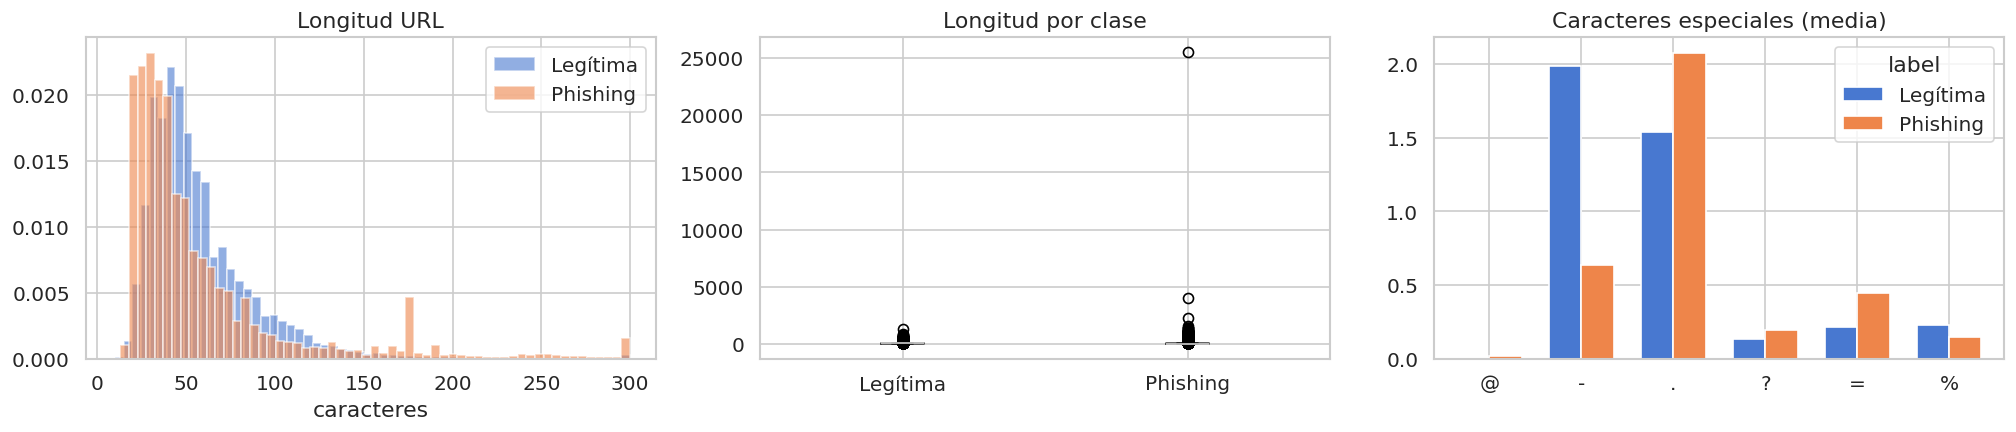

              count    mean      std     min     25%     50%     75%  \
label                                                                  
Legítima 49888.0000 58.1000  33.5000 10.0000 37.0000 50.0000 69.0000   
Phishing 49997.0000 60.6000 131.7000  8.0000 29.0000 41.0000 64.0000   

                max  
label                
Legítima  1323.0000  
Phishing 25523.0000  


In [8]:
df_raw["url_length"] = df_raw["url"].str.len()
class_map = {0: "Legítima", 1: "Phishing"}

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

for lbl, grp in df_raw.groupby(TARGET_COL):
    axes[0].hist(grp["url_length"].clip(upper=300), bins=60,
                 alpha=0.6, label=class_map[lbl], density=True)
axes[0].set_title("Longitud URL"); axes[0].set_xlabel("caracteres"); axes[0].legend()

df_raw.boxplot(column="url_length", by=TARGET_COL, ax=axes[1], notch=False)
plt.sca(axes[1]); plt.title("Longitud por clase")
axes[1].set_xticklabels([class_map[0], class_map[1]]); axes[1].set_xlabel("")

chars = ["@", "-", ".", "?", "=", "%"]
means = (df_raw.groupby(TARGET_COL)["url"]
         .apply(lambda s: pd.Series({c: s.str.count(re.escape(c)).mean() for c in chars}))
         .unstack(0).rename(columns=class_map))
means.plot.bar(ax=axes[2], width=0.7)
axes[2].set_title("Caracteres especiales (media)"); axes[2].tick_params(axis="x", rotation=0)

plt.suptitle(""); plt.tight_layout()
FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(str(FIG_DIR / "eda.png"), bbox_inches="tight"); plt.show()
print(df_raw.groupby(TARGET_COL)["url_length"].describe().rename(index=class_map).round(1))

## 3 · Feature Engineering
> 40 características léxicas — sin acceso externo en inferencia.

In [9]:
def normalize_url(url: str) -> str:
    """Añade esquema si falta + quita subdomains neutros de un nivel."""
    url = str(url).strip()
    if not url.startswith(("http://", "https://", "ftp://")):
        url = "http://" + url
    try:
        ext = tldextract.extract(url)
        if ext.subdomain.lower() in NEUTRAL_SUBS and ext.domain and ext.suffix:
            url = url.replace(
                f"{ext.subdomain}.{ext.domain}.{ext.suffix}",
                f"{ext.domain}.{ext.suffix}", 1,
            )
    except Exception:
        pass
    return url


def extract_features(url: str) -> dict:
    url  = normalize_url(url)
    feat = {}

    feat["url_length"]      = len(url)
    feat["path_length"]     = 0
    feat["query_length"]    = 0
    feat["hostname_length"] = 0
    feat["has_port"]        = 0
    feat["n_subdomains"]    = 0
    # scheme_https excluido: ISCX no tiene esquemas → bias de formato vs PhishTank

    try:
        p = urlparse(url)
        feat["path_length"]     = len(p.path)
        feat["query_length"]    = len(p.query)
        feat["hostname_length"] = len(p.hostname or "")
        feat["has_port"]        = int(bool(p.port))
        hn = p.hostname or ""
        feat["n_subdomains"]    = max(len(hn.split(".")) - 2, 0)
    except Exception:
        pass

    feat["count_dots"]       = url.count(".")
    feat["count_hyphens"]    = url.count("-")
    feat["count_underscores"]= url.count("_")
    feat["count_slash"]      = url.count("/")
    feat["count_at"]         = url.count("@")
    feat["count_question"]   = url.count("?")
    feat["count_equals"]     = url.count("=")
    feat["count_ampersand"]  = url.count("&")
    feat["count_percent"]    = url.count("%")
    feat["count_digits"]     = sum(c.isdigit() for c in url)
    feat["count_params"]     = len(re.findall(r"[?&][^=&]+=", url))

    n = max(len(url), 1)
    feat["digit_ratio"]   = feat["count_digits"] / n
    feat["special_ratio"] = (feat["count_dots"] + feat["count_hyphens"] +
                              feat["count_at"]   + feat["count_percent"]) / n

    feat["has_ip"]           = int(bool(re.search(r"(?:^|//)\d{1,3}(\.\d{1,3}){3}", url)))
    feat["has_at"]           = int("@" in url)
    feat["has_double_slash"] = int("//" in url[8:])
    feat["has_hex"]          = int("%" in url)
    feat["has_shortener"]    = int(bool(re.search(
        r"bit\.ly|goo\.gl|tinyurl|ow\.ly|t\.co|is\.gd|"
        r"buff\.ly|adf\.ly|rebrand\.ly|cutt\.ly|v\.gd", url, re.I)))
    feat["https_in_path"]    = int("https" in url[8:].lower())
    feat["has_login_kw"]     = int(bool(re.search(
        r"login|signin|sign-in|verify|secure|update|account|"
        r"banking|paypal|ebay|amazon|apple|microsoft|facebook|webscr|"
        r"iniciar-sesion|contrasena|clave|acceso|validar|confirmar|"
        r"netflix|spotify|mercadolibre|bancolombia|davivienda|nequi|"
        r"instagram|whatsapp|telegram|coinbase|binance|wallet|crypto",
        url, re.I)))
    feat["suspicious_tld"]   = int(bool(re.search(
        r"\.(tk|ml|ga|cf|gq|xyz|top|club|work|date|download|"
        r"racing|science|bid|win|stream|loan|review|trade|click|"
        r"buzz|cyou|cfd|sbs|hair|skin|beauty|mom|bond|"
        r"lol|monster|observer|quest|rest|zip|mov)(?:/|$)",
        url, re.I)))
    feat["has_punycode"]     = int("xn--" in url.lower())
    feat["max_token_len"]    = len(max(re.split(r"[.\-_/?=&]", url) or [""], key=len))
    feat["longest_digit_seq"]= len(max(re.findall(r"\d+", url) or [""], key=len))

    try:
        ext = tldextract.extract(url)
        feat["domain_len"]     = len(ext.domain)
        feat["tld_len"]        = len(ext.suffix)
        feat["subdomain_len"]  = len(ext.subdomain)
        feat["n_dots_sub"]     = ext.subdomain.count(".") if ext.subdomain else 0
        feat["domain_digit"]   = int(any(c.isdigit() for c in ext.domain))
        feat["domain_hyphen"]  = int("-" in ext.domain)

        domain_name = ext.domain.lower()
        vowels = set("aeiou")
        if domain_name:
            consonant_count = sum(1 for c in domain_name if c.isalpha() and c not in vowels)
            feat["consonant_ratio"] = consonant_count / max(len(domain_name), 1)
            max_consec = 0
            cur = 0
            for c in domain_name:
                if c.isalpha() and c not in vowels:
                    cur += 1
                    max_consec = max(max_consec, cur)
                else:
                    cur = 0
            feat["max_consonant_seq"] = max_consec
        else:
            feat["consonant_ratio"] = 0.0
            feat["max_consonant_seq"] = 0
    except Exception:
        feat["domain_len"] = feat["tld_len"] = feat["subdomain_len"] = 0
        feat["n_dots_sub"] = feat["domain_digit"] = feat["domain_hyphen"] = 0
        feat["consonant_ratio"] = 0.0
        feat["max_consonant_seq"] = 0

    try:
        hn_raw = url.split("//")[-1].split("/")[0]
        if hn_raw:
            probs = [v / len(hn_raw) for v in Counter(hn_raw).values()]
            feat["hostname_entropy"] = -sum(p * np.log2(p) for p in probs if p > 0)
        else:
            feat["hostname_entropy"] = 0.0
    except Exception:
        feat["hostname_entropy"] = 0.0

    try:
        ext2     = tldextract.extract(url)
        root_dom = f"{ext2.domain}.{ext2.suffix}".lower()
        feat["domain_in_top10k"] = int(root_dom in TRANCO_TOP10K)
    except Exception:
        feat["domain_in_top10k"] = 0

    return feat


tests = [
    ("http://192.168.1.1@secure-paypal.tk/verify?user=admin",  1),
    ("https://www.github.com/scikit-learn/scikit-learn",        0),
    ("http://login-secure-amazon-update.xyz/account",           1),
    ("https://docs.python.org/3/library/os.html",               0),
    ("http://bit.ly/2xFakePhish?redir=paypal.com.ru",           1),
    ("http://xn--pypal-4ve.com/login",                          1),
]
print(f"Features: {len(extract_features(tests[0][0]))}  (sin scheme_https)\n")
print(f"{'Expected':<10} {'Hints':>5}   Norm URL")
print("-" * 65)
for url, expected in tests:
    f = extract_features(url)
    hints = (f["has_ip"] + f["suspicious_tld"] + f["has_login_kw"] +
             f["has_shortener"] + f["has_at"] + f["has_punycode"])
    print(f"{expected:<10} {hints:>5}   {normalize_url(url)[:50]}")


Features: 40  (sin scheme_https)

Expected   Hints   Norm URL
-----------------------------------------------------------------
1              4   http://192.168.1.1@secure-paypal.tk/verify?user=ad
0              0   https://github.com/scikit-learn/scikit-learn
1              2   http://login-secure-amazon-update.xyz/account
0              0   https://python.org/3/library/os.html
1              2   http://bit.ly/2xFakePhish?redir=paypal.com.ru
1              2   http://xn--pypal-4ve.com/login


In [10]:
try:
    from tqdm.auto import tqdm; tqdm.pandas()
    records = df_raw["url"].progress_apply(extract_features)
except ImportError:
    records = df_raw["url"].apply(extract_features)

df_feat = pd.DataFrame(records.tolist())
df_feat[TARGET_COL] = df_raw[TARGET_COL].values

assert len(df_feat) == len(df_raw), "Row count mismatch after feature extraction"
nulls = df_feat.isnull().sum()
assert nulls.sum() == 0, f"Unexpected nulls: {nulls[nulls > 0]}"

PROC_DIR.mkdir(parents=True, exist_ok=True)
df_feat.to_csv(str(PROC_DIR / "features.csv"), index=False)
print(f"Shape: {df_feat.shape[0]:,} rows x {df_feat.shape[1]} features")
df_feat.describe().T[["mean", "std", "min", "max"]].round(3)

  0%|          | 0/99885 [00:00<?, ?it/s]

Shape: 99,885 rows x 41 features


,mean,std,min,max
url_length,59.2050,96.0150,8.0000,25523.0000
path_length,27.7330,27.8700,0.0000,630.0000
query_length,8.7160,42.8080,0.0000,3975.0000
hostname_length,14.7920,7.9940,0.0000,121.0000
has_port,0.0060,0.0770,0.0000,1.0000
n_subdomains,0.2580,0.5050,0.0000,7.0000
count_dots,1.7760,1.2490,0.0000,29.0000
count_hyphens,1.3110,2.5330,0.0000,50.0000
count_underscores,0.2760,1.2430,0.0000,200.0000
count_slash,4.3950,1.6270,2.0000,26.0000


## 4 · Preprocessing

In [11]:
FEATURE_COLS = [c for c in df_feat.columns if c != TARGET_COL]
X = df_feat[FEATURE_COLS]
y = df_feat[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

print(f"Train : {len(X_train):,}  |  Test : {len(X_test):,}")
print(f"Class balance — train: {y_train.mean():.1%}   test: {y_test.mean():.1%}")
print(f"Features : {len(FEATURE_COLS)}")


Train : 79,908  |  Test : 19,977
Class balance — train: 50.1%   test: 50.1%
Features : 40


## 5 · Model Comparison

In [12]:
def _pipe(clf):
    return Pipeline([("pre", preprocessor), ("clf", clf)])

candidates = {
    "LogisticRegression": _pipe(
        LogisticRegression(C=1.0, solver="lbfgs", max_iter=1000,
                           random_state=RANDOM_STATE, class_weight="balanced")),
    "RandomForest": _pipe(
        RandomForestClassifier(n_estimators=300, min_samples_leaf=3,
                               n_jobs=-1, random_state=RANDOM_STATE, class_weight="balanced")),
    "ExtraTrees": _pipe(
        ExtraTreesClassifier(n_estimators=300, min_samples_leaf=3,
                             n_jobs=-1, random_state=RANDOM_STATE, class_weight="balanced")),
    "GradientBoosting": _pipe(
        GradientBoostingClassifier(n_estimators=200, max_depth=6,
                                   learning_rate=0.1, random_state=RANDOM_STATE)),
}

if HAS_XGB:
    candidates["XGBoost"] = _pipe(
        xgb.XGBClassifier(n_estimators=300, max_depth=7, learning_rate=0.05,
                           use_label_encoder=False, eval_metric="logloss",
                           n_jobs=-1, random_state=RANDOM_STATE, verbosity=0))
if HAS_LGB:
    candidates["LightGBM"] = _pipe(
        lgb.LGBMClassifier(n_estimators=300, max_depth=7, learning_rate=0.05,
                            n_jobs=-1, random_state=RANDOM_STATE, verbose=-1))

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = {"f1": "f1", "roc_auc": "roc_auc", "recall": "recall", "precision": "precision"}

cv_results = {}
for name, pipe in candidates.items():
    scores = cross_validate(pipe, X_train, y_train, cv=cv_strategy,
                            scoring=SCORING, n_jobs=-1)
    cv_results[name] = {m: scores[f"test_{m}"].mean() for m in SCORING}
    print(f"{name:<22}  F1={cv_results[name]['f1']:.4f}  AUC={cv_results[name]['roc_auc']:.4f}")

df_cv = pd.DataFrame(cv_results).T.round(4).sort_values("roc_auc", ascending=False)
print("\nFinal ranking:")
print(df_cv.to_string())


LogisticRegression      F1=0.7596  AUC=0.8844
RandomForest            F1=0.9066  AUC=0.9721
ExtraTrees              F1=0.9029  AUC=0.9714
GradientBoosting        F1=0.9034  AUC=0.9707
XGBoost                 F1=0.9013  AUC=0.9701
LightGBM                F1=0.8990  AUC=0.9690

Final ranking:
                       f1  roc_auc  recall  precision
RandomForest       0.9066   0.9721  0.8911     0.9226
ExtraTrees         0.9029   0.9714  0.8812     0.9256
GradientBoosting   0.9034   0.9707  0.8898     0.9175
XGBoost            0.9013   0.9701  0.8873     0.9158
LightGBM           0.8990   0.9690  0.8851     0.9134
LogisticRegression 0.7596   0.8844  0.7058     0.8223


## 6 · Training & Evaluation

In [13]:
BEST_MODEL = df_cv["roc_auc"].idxmax()
pipeline = candidates[BEST_MODEL]
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

print(f"Model: {BEST_MODEL}")
print("=" * 52)
print(classification_report(y_test, y_pred,
      target_names=["Legítima", "Phishing"], digits=4))
print(f"ROC-AUC       : {roc_auc_score(y_test, y_prob):.4f}")
print(f"Avg Precision : {average_precision_score(y_test, y_prob):.4f}")


Model: RandomForest
              precision    recall  f1-score   support

    Legítima     0.8997    0.9246    0.9120      9978
    Phishing     0.9226    0.8971    0.9097      9999

    accuracy                         0.9108     19977
   macro avg     0.9112    0.9109    0.9108     19977
weighted avg     0.9112    0.9108    0.9108     19977

ROC-AUC       : 0.9730
Avg Precision : 0.9759


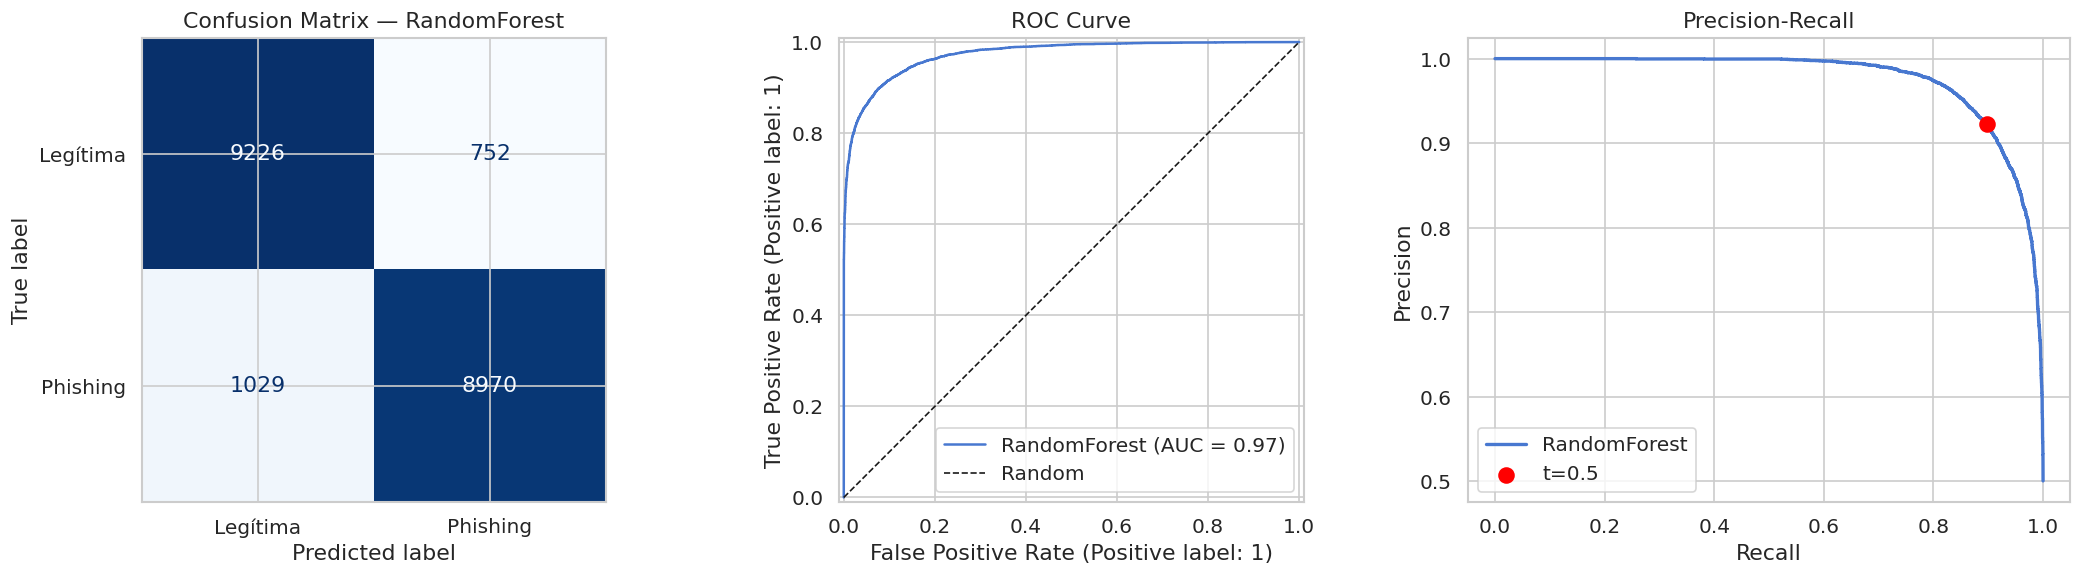

TP=8,970  FP=752  FN=1,029  TN=9,226
Phishing detectado : 89.7%   Falsa alarma : 7.5%


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Legítima", "Phishing"]).plot(
    ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title(f"Confusion Matrix — {BEST_MODEL}")

RocCurveDisplay.from_predictions(y_test, y_prob, name=BEST_MODEL, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Random"); axes[1].legend()
axes[1].set_title("ROC Curve")

prec_arr, rec_arr, thr_arr = precision_recall_curve(y_test, y_prob)
axes[2].plot(rec_arr, prec_arr, lw=2, label=BEST_MODEL)
idx = np.argmin(np.abs(thr_arr - 0.5))
axes[2].scatter(rec_arr[idx], prec_arr[idx], c="red", s=80, zorder=5, label="t=0.5")
axes[2].set_xlabel("Recall"); axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall"); axes[2].legend()

plt.tight_layout()
FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(str(FIG_DIR / "evaluation.png"), bbox_inches="tight"); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TP={tp:,}  FP={fp:,}  FN={fn:,}  TN={tn:,}")
print(f"Phishing detectado : {tp/(tp+fn):.1%}   Falsa alarma : {fp/(fp+tn):.1%}")

## 7 · Feature Importance

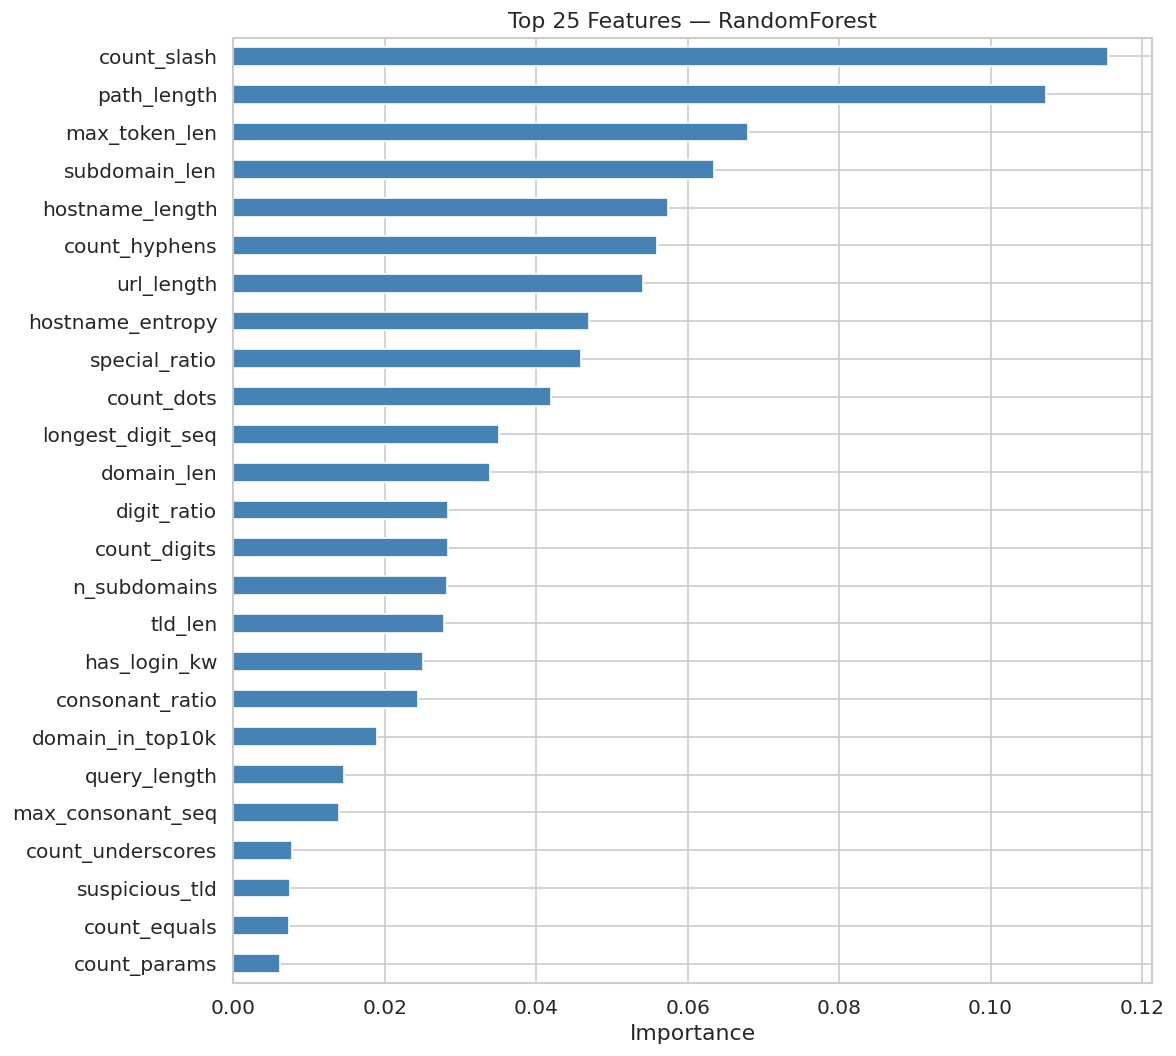

Top 15:
count_slash         0.1156
path_length         0.1073
max_token_len       0.0679
subdomain_len       0.0635
hostname_length     0.0574
count_hyphens       0.0560
url_length          0.0542
hostname_entropy    0.0470
special_ratio       0.0459
count_dots          0.0420
longest_digit_seq   0.0350
domain_len          0.0339
digit_ratio         0.0284
count_digits        0.0283
n_subdomains        0.0282


In [15]:
clf = pipeline.named_steps["clf"]

if hasattr(clf, "feature_importances_"):
    imp = pd.Series(clf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(10, 9))
    imp.head(25).sort_values().plot.barh(ax=ax, color="steelblue")
    ax.set_xlabel("Importance"); ax.set_title(f"Top 25 Features — {BEST_MODEL}")
    plt.tight_layout()
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    plt.savefig(str(FIG_DIR / "feature_importance.png"), bbox_inches="tight"); plt.show()
    print("Top 15:"); print(imp.head(15).to_string())
elif hasattr(clf, "coef_"):
    imp = pd.Series(np.abs(clf.coef_[0]), index=FEATURE_COLS).sort_values(ascending=False)
    print("Top 15 |coef|:"); print(imp.head(15).to_string())

## 8 · Decision Threshold

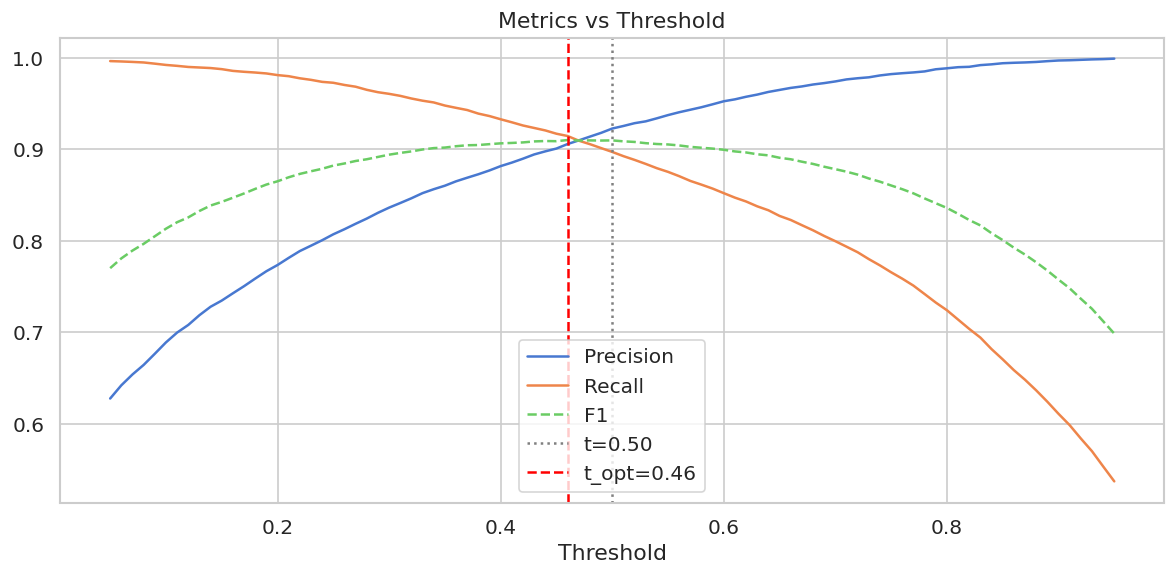

Threshold: 0.46  F1=0.9101  Recall=0.9145  Precision=0.9057


In [16]:
rows = []
for t in np.linspace(0.05, 0.95, 91):
    yp    = (y_prob >= t).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, yp).ravel()
    rows.append({
        "threshold": round(float(t), 2),
        "f1":        f1_score(y_test, yp, zero_division=0),
        "recall":    tp_t / max(tp_t + fn_t, 1),
        "precision": tp_t / max(tp_t + fp_t, 1),
        "fpr":       fp_t / max(fp_t + tn_t, 1),
    })

df_thr = pd.DataFrame(rows)
DECISION_THRESHOLD = float(df_thr.loc[df_thr["f1"].idxmax(), "threshold"])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_thr["threshold"], df_thr["precision"], label="Precision")
ax.plot(df_thr["threshold"], df_thr["recall"],    label="Recall")
ax.plot(df_thr["threshold"], df_thr["f1"], "--",  label="F1")
ax.axvline(0.5,                color="gray", ls=":", label="t=0.50")
ax.axvline(DECISION_THRESHOLD, color="red",  ls="--",
           label=f"t_opt={DECISION_THRESHOLD:.2f}")
ax.set_xlabel("Threshold"); ax.set_title("Metrics vs Threshold"); ax.legend()
plt.tight_layout()
FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(str(FIG_DIR / "threshold.png"), bbox_inches="tight"); plt.show()

best = df_thr[df_thr["threshold"] == DECISION_THRESHOLD].iloc[0]
print(f"Threshold: {DECISION_THRESHOLD}  F1={best['f1']:.4f}  "
      f"Recall={best['recall']:.4f}  Precision={best['precision']:.4f}")

## 9 · Persistence

In [20]:
import sklearn
import os
import json

meta = {
    "model":           BEST_MODEL,
    "features":        FEATURE_COLS,
    "threshold":       DECISION_THRESHOLD,
    "test_roc_auc":    round(float(roc_auc_score(y_test, y_prob)), 4),
    "avg_precision":   round(float(average_precision_score(y_test, y_prob)), 4),
    "train_size":      int(len(X_train)),
    "test_size":       int(len(X_test)),
    "sklearn_version": sklearn.__version__,
}

os.makedirs("models", exist_ok=True)
model_path = os.path.join("models", "pipeline.joblib")
meta_path = os.path.join("models", "meta.json")

joblib.dump(pipeline, MODEL_DIR / "pipeline.joblib", compress=4)
(MODEL_DIR / "meta.json").write_text(json.dumps(meta, indent=2))

print(f"Saved -> {MODEL_DIR / 'pipeline.joblib'}")
print(json.dumps(meta, indent=2))

Saved -> models/pipeline.joblib
{
  "model": "RandomForest",
  "features": [
    "url_length",
    "path_length",
    "query_length",
    "hostname_length",
    "has_port",
    "n_subdomains",
    "count_dots",
    "count_hyphens",
    "count_underscores",
    "count_slash",
    "count_at",
    "count_question",
    "count_equals",
    "count_ampersand",
    "count_percent",
    "count_digits",
    "count_params",
    "digit_ratio",
    "special_ratio",
    "has_ip",
    "has_at",
    "has_double_slash",
    "has_hex",
    "has_shortener",
    "https_in_path",
    "has_login_kw",
    "suspicious_tld",
    "has_punycode",
    "max_token_len",
    "longest_digit_seq",
    "domain_len",
    "tld_len",
    "subdomain_len",
    "n_dots_sub",
    "domain_digit",
    "domain_hyphen",
    "consonant_ratio",
    "max_consonant_seq",
    "hostname_entropy",
    "domain_in_top10k"
  ],
  "threshold": 0.46,
  "test_roc_auc": 0.973,
  "avg_precision": 0.9759,
  "train_size": 79908,
  "test_size": 1

## 10 · PhishingDetector — API de inferencia

Clase reutilizable para clasificar URLs en cualquier contexto (scripts, APIs REST, batch jobs).

```python
# Uso mínimo
from detector import PhishingDetector
d = PhishingDetector()
d.detect('http://example.com')   # -> dict con veredicto
d.batch(['url1', 'url2'])         # -> DataFrame
```


In [21]:
class PhishingDetector:
    def __init__(self, model_dir: Path = MODEL_DIR):
        model_path = model_dir / "pipeline.joblib"
        if not model_path.exists():
            raise FileNotFoundError(f"No model artifact found at {model_path}. You must run the persistence cell first.")
        self._pipe     = joblib.load(model_path)
        meta_path      = model_dir / "meta.json"
        meta           = json.loads(meta_path.read_text()) if meta_path.exists() else {}
        self.features  = meta.get("features")
        self.threshold = meta.get("threshold", 0.5)
        self.model     = meta.get("model", model_path.name)

    def _featurize(self, urls: list) -> pd.DataFrame:
        frame = pd.DataFrame([extract_features(u) for u in urls])
        return frame.reindex(columns=self.features, fill_value=0) if self.features else frame

    def batch(self, urls: list, threshold: float = None) -> pd.DataFrame:
        t     = threshold if threshold is not None else self.threshold
        probs = self._pipe.predict_proba(self._featurize(urls))[:, 1]
        return pd.DataFrame({
            "url":         urls,
            "probability": probs.round(4),
            "phishing":    (probs >= t).astype(int),
            "verdict":     ["PHISHING" if p >= t else "LEGÍTIMA" for p in probs],
        })

    def detect(self, url: str) -> dict:
        f = extract_features(url)
        try:
            ext = tldextract.extract(url)
            root = f"{ext.domain}.{ext.suffix}".lower()
            if TRANCO_TOP10K and root in TRANCO_TOP10K:
                if f.get("has_shortener", 0) == 0 and f.get("has_login_kw", 0) == 0:
                    return {
                        "url": url,
                        "probability": 0.01,
                        "phishing": False,
                        "verdict": "LEGÍTIMA",
                        "note": "Dominio en Top-10k — override aplicado",
                    }
        except Exception:
            pass

        row = self.batch([url]).iloc[0]
        return {"url": url, "probability": float(row["probability"]),
                "phishing": bool(row["phishing"]), "verdict": row["verdict"]}

    def explain(self, url: str) -> dict:
        result = self.detect(url)
        f      = extract_features(url)
        flags  = []
        if f["has_ip"]:            flags.append("IP in URL")
        if f["has_at"]:            flags.append("@ symbol")
        if f["suspicious_tld"]:    flags.append("suspicious TLD")
        if f["has_login_kw"]:      flags.append("login/account keywords")
        if f["has_shortener"]:     flags.append("URL shortener")
        if f["count_dots"] > 5:    flags.append(f"{f['count_dots']} dots")
        if f["has_double_slash"]:  flags.append("double-slash in path")
        if f["hostname_entropy"] > 4.0:
            flags.append(f"high entropy ({f['hostname_entropy']:.2f})")
        if f["has_punycode"]:      flags.append("punycode domain")
        if f["domain_digit"]:      flags.append("digit in domain name")
        return {**result, "flags": flags}


if "FEATURE_COLS" in globals() and (MODEL_DIR / "meta.json").exists():
    detector = PhishingDetector()
    print(f"Model: {detector.model}   threshold={detector.threshold}\n")

    test_cases = [
        "http://192.168.0.1@secure-paypal-login.tk/verify?user=admin",
        "https://www.github.com/anthropics/anthropic-sdk-python",
        "http://login-secure-update-account.xyz/amazon/signin",
        "https://docs.python.org/3/library/urllib.parse.html",
        "http://bit.ly/3xFakeLink?redirect=paypal-secure.ru",
        "https://www.linkedin.com/in/johndoe",
        "http://xn--pypal-4ve.com/login",
        "https://stackoverflow.com/questions/tagged/pandas",
        "https://docs.google.com/login",
    ]

    for url in test_cases:
        r = detector.explain(url)
        icon = "[PHISHING]" if r["phishing"] else "[LEGÍTIMA ]"
        print(f"{icon} {r['probability']:.3f}  {url[:58]}")
        if r["flags"]:
            print(f"           flags: {', '.join(r['flags'])}")
else:
    print("Skipping detector smoke test: trained model metadata is not available yet.")

Model: RandomForest   threshold=0.46

[PHISHING] 0.792  http://192.168.0.1@secure-paypal-login.tk/verify?user=admi
           flags: IP in URL, @ symbol, suspicious TLD, login/account keywords, high entropy (4.42)
[LEGÍTIMA ] 0.010  https://www.github.com/anthropics/anthropic-sdk-python
[PHISHING] 0.801  http://login-secure-update-account.xyz/amazon/signin
           flags: suspicious TLD, login/account keywords, high entropy (4.08)
[LEGÍTIMA ] 0.010  https://docs.python.org/3/library/urllib.parse.html
[PHISHING] 0.699  http://bit.ly/3xFakeLink?redirect=paypal-secure.ru
           flags: login/account keywords, URL shortener
[LEGÍTIMA ] 0.010  https://www.linkedin.com/in/johndoe
[PHISHING] 0.862  http://xn--pypal-4ve.com/login
           flags: login/account keywords, punycode domain, digit in domain name
[LEGÍTIMA ] 0.010  https://stackoverflow.com/questions/tagged/pandas
[LEGÍTIMA ] 0.283  https://docs.google.com/login
           flags: login/account keywords


## 11 · Extensiones y próximos pasos

### Más datasets
| Dataset | URL | Tamaño |
|---------|-----|--------|
| ISCX-URL-2016 | Kaggle / UNB CIC | ~100k |
| PhiUSIIL (2023) | IEEE DataPort | ~235k |
| URLhaus bulk | urlhaus.abuse.ch/downloads | diario |

### Features opcionales (requieren APIs)
- `domain_age_days` — python-whois
- `cert_days_left` — SSL cert via ssl module
- `redirect_count` — requests.head() con allow_redirects=True
- `page_has_form` — BeautifulSoup del HTML

### Producción
```python
# FastAPI wrapper
from fastapi import FastAPI
app = FastAPI()
_d = PhishingDetector()

@app.get('/check')
def check(url: str): return _d.explain(url)
```
